# **ETTh1 Dataset Analysis**
- Using Google Colab for execution

In [ ]:
# ONLY DO THIS ONCE WHEN INITIALIZING THE FILE

# Cloning the GitHub Repo into Google Colab -- REQUIRES THE REPO TO BE PUBLIC
# !git clone https://github.com/jauric/TUB-SS-26_Deep-Learning-Time-Series.git

# Navigating Colab into the cloned repo
# %cd TUB-SS-26_Deep-Learning-Time-Series

In [4]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [5]:
ETTh1_link = "~/PythonWorkspace/timeseries/data/ETTh1.csv"

data_ETTh1 = pd.read_csv(ETTh1_link)
data_ETTh1.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


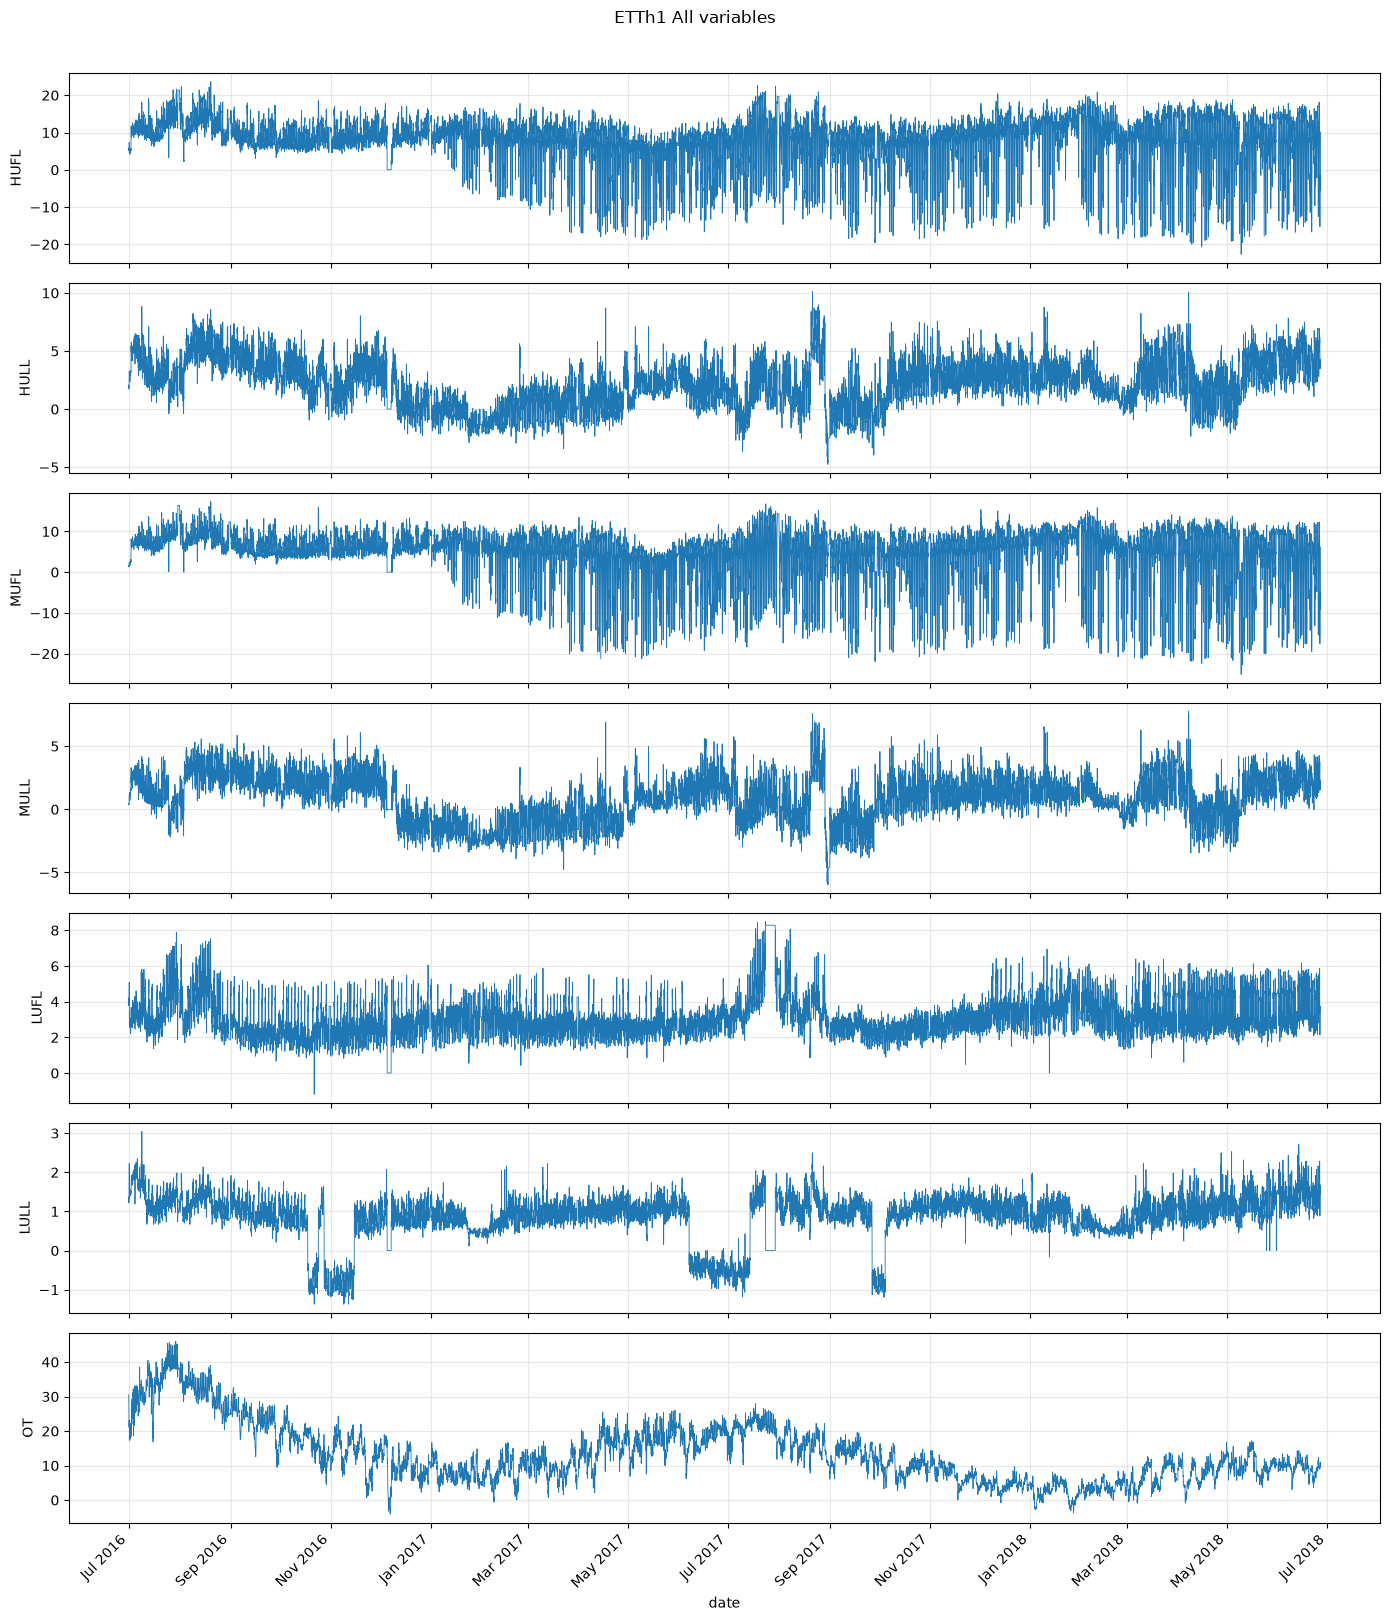

In [6]:
dates = pd.to_datetime(data_ETTh1["date"])

data_ETTh1 = data_ETTh1.set_index("date")

# Visualize all 7 features
fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)
for ax, col in zip(axes, data_ETTh1.columns):
    ax.plot(dates, data_ETTh1[col], linewidth=0.6)
    ax.set_ylabel(col)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

fig.suptitle("ETTh1 All variables", y=1.01)
plt.tight_layout()
plt.show()

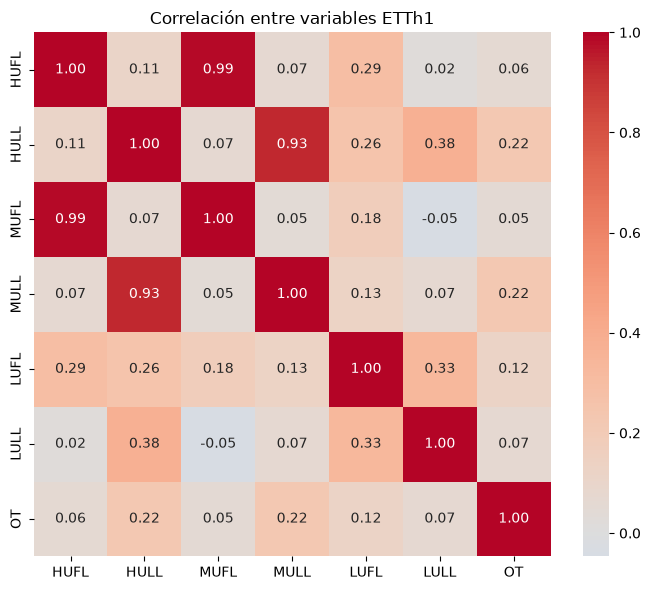

In [12]:
import seaborn as sns

corr = data_ETTh1.corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables ETTh1")
plt.tight_layout()
plt.show()

In [14]:
df = data_ETTh1
lags = range(0, 25)  # hasta 24h de retraso
for col in ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL"]:
    corrs = [df[col].shift(lag).corr(df["OT"]) for lag in lags]
    best_lag = np.argmax(np.abs(corrs))
    print(f"{col}: mejor correlación = {corrs[best_lag]:.3f} en lag={best_lag}h")

HUFL: mejor correlación = 0.147 en lag=15h
HULL: mejor correlación = 0.263 en lag=10h
MUFL: mejor correlación = 0.141 en lag=15h
MULL: mejor correlación = 0.254 en lag=10h
LUFL: mejor correlación = 0.133 en lag=7h
LULL: mejor correlación = 0.079 en lag=6h


In [15]:
for lag in [1, 6, 10, 15, 24]:
    print(f"OT autocorr en lag={lag}h: {df['OT'].autocorr(lag):.3f}")

OT autocorr en lag=1h: 0.994
OT autocorr en lag=6h: 0.966
OT autocorr en lag=10h: 0.949
OT autocorr en lag=15h: 0.939
OT autocorr en lag=24h: 0.941
